# Experiment No. 3
## Statistical Analysis and Hypothesis Testing using Python

* **Name:** Akshit Negi
* **Course & Branch:** B.TECH CSE
* **CUID:** CU24250214
* **SEM & Section:** 5th SEM , "B"

**Aim:** To perform statistical analysis and hypothesis testing on a real-world dataset using Python in order to identify relationships between variables, validate assumptions, and support data-driven decision-making.

**Dataset used:** Titanic Survival Dataset (loaded via the `seaborn` library, works directly in Google Colab with no upload required).

---

### Step 1: Select a real-world dataset

We select the **Titanic Survival Dataset**, which contains passenger information such as age, fare, class, and survival status. It is loaded directly using `seaborn.load_dataset()`.

In [1]:
import seaborn as sns

# Load the Titanic dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Step 2: Import the required Python libraries

Import Pandas, NumPy, SciPy, Matplotlib, Seaborn, and Statsmodels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

pd.set_option('display.max_columns', None)
print("Libraries imported successfully")

Libraries imported successfully


### Step 3: Load the dataset and calculate descriptive statistics

Calculate mean, median, mode, variance, and standard deviation for relevant numerical features (e.g., `age`, `fare`).

In [3]:
# Basic info
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

# Descriptive statistics for numerical columns
desc = df[['age', 'fare', 'sibsp', 'parch']].describe()
print("\nDescriptive Statistics:\n", desc)

# Mean, Median, Mode, Variance, Std Dev for 'age' and 'fare'
for col in ['age', 'fare']:
    print(f"\n--- {col} ---")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing values:
 survived         0
pclass           0
sex              0

### Step 4: Analyze relationships between variables

Calculate the Pearson correlation coefficient between numerical variables and visualize the correlation matrix as a heatmap.

Pearson Correlation Matrix:
           survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.359653 -0.077221 -0.017358  0.093317  0.268189
pclass   -0.359653  1.000000 -0.369226  0.067247  0.025683 -0.554182
age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
sibsp    -0.017358  0.067247 -0.308247  1.000000  0.383820  0.138329
parch     0.093317  0.025683 -0.189119  0.383820  1.000000  0.205119
fare      0.268189 -0.554182  0.096067  0.138329  0.205119  1.000000


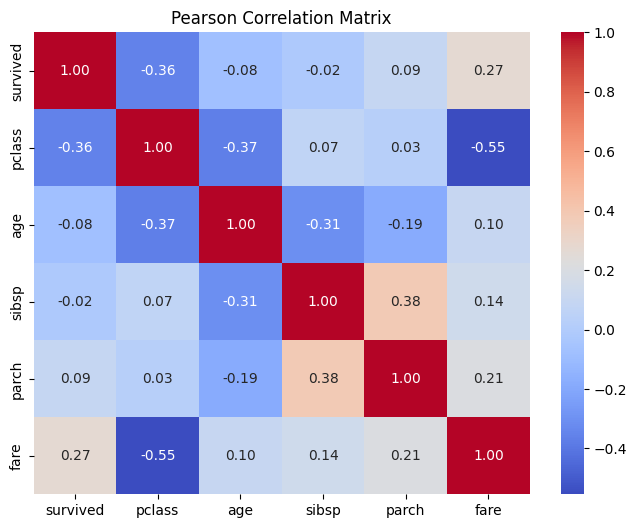

In [4]:
numeric_df = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].dropna()

corr_matrix = numeric_df.corr(method='pearson')
print("Pearson Correlation Matrix:\n", corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation Matrix")
plt.show()

### Step 5: Formulate the Null and Alternative Hypotheses

**Business problem:** Is there a significant difference in the average **fare** paid by passengers who **survived** versus those who **did not survive**?

- **Null Hypothesis (H₀):** There is no significant difference in the mean fare between survivors and non-survivors.
- **Alternative Hypothesis (H₁):** There is a significant difference in the mean fare between survivors and non-survivors.

Significance level: **α = 0.05**

### Step 6: Perform an Independent Sample t-test

Compare the mean `fare` of the two groups (survived vs. not survived) and interpret the p-value.

In [5]:
survived_fare = df[df['survived'] == 1]['fare'].dropna()
not_survived_fare = df[df['survived'] == 0]['fare'].dropna()

t_stat, p_value = stats.ttest_ind(survived_fare, not_survived_fare, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Result: Reject H0 -> Significant difference in mean fare between the two groups.")
else:
    print("Result: Fail to reject H0 -> No significant difference in mean fare.")

T-statistic: 6.839099259085254
P-value: 2.6993323503141236e-11
Result: Reject H0 -> Significant difference in mean fare between the two groups.


### Step 7: Apply One-Way ANOVA

Test whether there is a statistically significant difference in `fare` among multiple passenger classes (`pclass`).

In [6]:
class1 = df[df['pclass'] == 1]['fare'].dropna()
class2 = df[df['pclass'] == 2]['fare'].dropna()
class3 = df[df['pclass'] == 3]['fare'].dropna()

f_stat, p_val_anova = stats.f_oneway(class1, class2, class3)

print("F-statistic:", f_stat)
print("P-value:", p_val_anova)

if p_val_anova < 0.05:
    print("Result: Reject H0 -> Significant difference in mean fare across passenger classes.")
else:
    print("Result: Fail to reject H0 -> No significant difference across passenger classes.")

F-statistic: 242.34415651744814
P-value: 1.0313763209141171e-84
Result: Reject H0 -> Significant difference in mean fare across passenger classes.


### Step 8: Build a simple Linear Regression model

Analyze the relationship between **age** and **fare** using simple linear regression.

                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     6.632
Date:                Tue, 08 Sep 2026   Prob (F-statistic):             0.0102
Time:                        16:22:57   Log-Likelihood:                -3843.0
No. Observations:                 714   AIC:                             7690.
Df Residuals:                     712   BIC:                             7699.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.3009      4.492      5.410      0.0

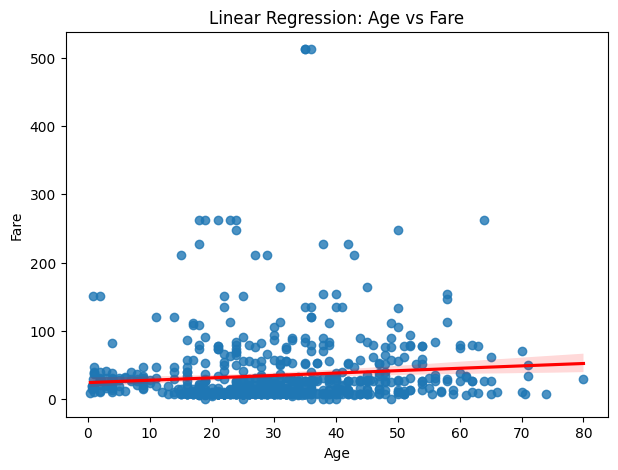

In [7]:
reg_df = df[['age', 'fare']].dropna()

X = sm.add_constant(reg_df['age'])   # independent variable
y = reg_df['fare']                    # dependent variable

model = sm.OLS(y, X).fit()
print(model.summary())

# Visualize regression line
plt.figure(figsize=(7, 5))
sns.regplot(x='age', y='fare', data=reg_df, line_kws={'color': 'red'})
plt.title("Linear Regression: Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

### Step 9: Interpret the statistical outputs

- **p-value:** From the t-test and ANOVA above, compare the p-value with α = 0.05 to decide whether to reject H₀.
- **Confidence intervals:** Seen in the OLS regression summary (`model.summary()`), e.g., the 95% CI for the coefficient of `age`.
- **Regression coefficients:** The `coef` value for `age` shows how much `fare` changes for a one-unit increase in `age`.
- **R² score:** Indicates the proportion of variance in `fare` explained by `age`.

In [8]:
print("R-squared:", model.rsquared)
print("Coefficients:\n", model.params)
print("95% Confidence Intervals:\n", model.conf_int())

R-squared: 0.009228809267447624
Coefficients:
 const    24.300901
age       0.349964
dtype: float64
95% Confidence Intervals:
                0          1
const  15.481351  33.120452
age     0.083165   0.616762


### Step 10: Summarize the findings

- Descriptive statistics gave an overview of the central tendency and spread of `age` and `fare`.
- The correlation matrix showed the strength and direction of relationships between numerical variables.
- The t-test indicated whether survival status is associated with a significant difference in fare paid.
- ANOVA showed whether passenger class significantly affects fare.
- Linear regression quantified the relationship between age and fare, with R² indicating how well age explains fare variation.
- Such statistical analysis helps organizations validate assumptions with evidence before applying machine learning models, supporting more reliable, data-driven business decisions.

---

## Questions

**Q1. What is the difference between descriptive statistics and inferential statistics?**

**Ans:** Descriptive statistics summarizes and describes the main features of a dataset (mean, median, mode, variance, standard deviation, graphs) without drawing conclusions beyond the data itself. Inferential statistics uses a sample of data to make predictions, generalizations, or decisions about a larger population, typically through hypothesis testing, confidence intervals, and regression analysis.

**Q2. Explain the concepts of the Null Hypothesis (H₀) and Alternative Hypothesis (H₁).**

**Ans:** The Null Hypothesis (H₀) is a statement that assumes no effect, no difference, or no relationship exists between variables; it represents the status quo. The Alternative Hypothesis (H₁) is the statement that contradicts H₀, suggesting that a significant effect, difference, or relationship does exist. Hypothesis testing uses sample data to decide whether there is enough evidence to reject H₀ in favor of H₁.

**Q3. What is a p-value? How is it used to make statistical decisions?**

**Ans:** A p-value is the probability of obtaining a result at least as extreme as the observed one, assuming the null hypothesis is true. It is compared against a chosen significance level (α, commonly 0.05): if p-value < α, H₀ is rejected in favor of H₁ (the result is statistically significant); if p-value ≥ α, there is insufficient evidence to reject H₀.

**Q4. Differentiate between a t-test and ANOVA. In which situations is each test applied?**

**Ans:** A t-test compares the means of exactly two groups to determine if they are significantly different (e.g., fare of survivors vs. non-survivors). ANOVA (Analysis of Variance) compares the means of three or more groups simultaneously to check if at least one group differs significantly (e.g., fare across first, second, and third class). A t-test is used for two-group comparisons, while ANOVA is used when comparing more than two groups, avoiding the increased error rate of running multiple t-tests.

**Q5. What does the Pearson correlation coefficient indicate? What are its possible values?**

**Ans:** The Pearson correlation coefficient (r) measures the strength and direction of the linear relationship between two continuous variables. Its value ranges from -1 to +1: +1 indicates a perfect positive linear relationship, -1 indicates a perfect negative linear relationship, and 0 indicates no linear relationship. Values closer to ±1 indicate a stronger linear association.

**Q6. Explain the significance of R² (Coefficient of Determination) in Linear Regression.**

**Ans:** R² represents the proportion of variance in the dependent variable that is explained by the independent variable(s) in a regression model. It ranges from 0 to 1 (or 0% to 100%); a higher R² means the model explains more of the variability in the outcome, indicating a better fit, while a low R² suggests the predictors explain little of the variation.

**Q7. Why is statistical analysis important before applying machine learning algorithms?**

**Ans:** Statistical analysis helps understand data distributions, detect outliers, check relationships between variables, and validate assumptions (like normality and independence) before modeling. It ensures the right features are selected, prevents misleading conclusions, and improves model reliability, interpretability, and predictive performance.

**Q8. What assumptions should be satisfied before performing a t-test or ANOVA?**

**Ans:** Key assumptions include: (1) the data in each group should be approximately normally distributed, (2) observations should be independent of one another, (3) the groups should have homogeneity of variance (equal variances, especially important for standard ANOVA and the pooled t-test), and (4) the dependent variable should be measured on a continuous (interval/ratio) scale.

**Q9. How can regression analysis help organizations in forecasting and decision-making?**

**Ans:** Regression analysis models the relationship between a dependent variable and one or more independent variables, allowing organizations to predict future outcomes (e.g., sales, prices, demand) based on known inputs. It helps identify which factors most influence an outcome, quantify their impact, and make evidence-based decisions on pricing, resource allocation, and strategic planning.

**Q10. Give two real-world applications where hypothesis testing is commonly used in data analytics.**

**Ans:** (1) A/B testing in marketing or product design, to determine whether a new webpage layout or feature significantly improves conversion rates compared to the old version. (2) Healthcare and clinical trials, to test whether a new drug or treatment produces a statistically significant improvement in patient outcomes compared to a placebo or existing treatment.